# Cointegration & pairs trading — `qufin.timeseries.cointegration`

Two prices can each wander like a random walk — each **I(1)**, non-stationary —
yet a **linear combination** of them be **stationary**. They are tied together
by an invisible elastic band: when they drift apart, they snap back. This is
**cointegration**, and it is the rigorous foundation of statistical-arbitrage
pairs trading.

$$ y_t,\;x_t \sim I(1) \quad\text{but}\quad s_t = y_t - \beta x_t \sim I(0)\;\text{(stationary)} $$

The vector $(1,-\beta)$ is the **cointegrating vector**; $s_t$ is the
**spread**, and it mean-reverts (see the OU tutorial). Two formal tests:

* **Engle–Granger** — regress $y$ on $x$, then ADF-test the residuals. Simple,
  directional, gives $\beta$ directly.
* **Johansen** — an eigenvalue/VECM approach that handles many assets at once
  and tests the cointegration **rank** symmetrically.

**The cardinal sin** this guards against is **spurious regression**: two
*independent* random walks will show a high $R^2$ and "significant" $\beta$ by
pure chance. The cointegration test on the residuals is what separates a real
relationship from a coincidence.

**Roadmap**

1. Cointegration vs spurious regression — *seeing* the difference
2. Engle–Granger — recover $\beta$, test the spread, read the half-life
3. Johansen — rank, eigenvector, error-correction loadings
4. Kalman dynamic hedge ratio — when $\beta$ drifts
5. A real pair (EWA/EWC) + screening a universe
6. Hand-off — the `CointegrationPairsStrategy`


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from qufin.timeseries import engle_granger, johansen, adf
from qufin.timeseries.models import HedgeRatioFilter
from qufin.models.spread import hedge_ratio, spread as make_spread, half_life, rolling_zscore
from qufin.analysis import screen_pairs
from qufin.strategies import CointegrationPairsStrategy, PairsParams

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
rng = np.random.default_rng(0)


## 1. Cointegration vs spurious regression

We build two synthetic **log-price** pairs of the same length:

* **Cointegrated** — share a common stochastic trend; the spread is a
  stationary OU process. The prices move together and the gap reverts.
* **Independent** — two unrelated random walks. Any apparent relationship is an
  artefact.

Both regressions will look "good" ($R^2$ high). Only the residual ADF tells
them apart.


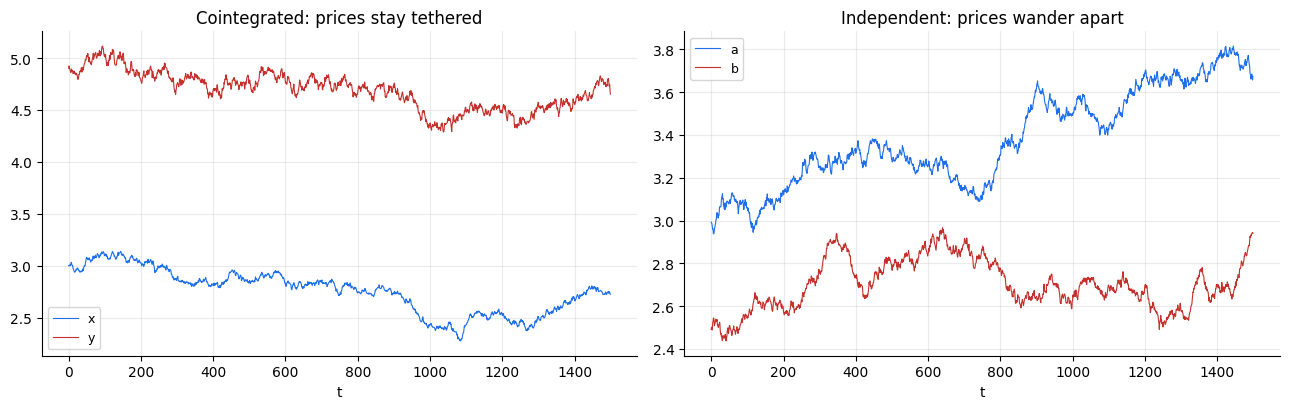

In [2]:
n = 1500
# --- Cointegrated pair (in log-price space) ---
common = np.cumsum(rng.normal(0, 0.012, n))          # shared I(1) trend
ou = np.zeros(n)                                       # stationary OU spread
for t in range(1, n):
    ou[t] = 0.94 * ou[t-1] + rng.normal(0, 0.02)
log_x = 3.0 + common
log_y = 2.5 + 0.80 * log_x + ou                       # cointegrated, true beta=0.80

# --- Independent pair ---
log_a = 3.0 + np.cumsum(rng.normal(0, 0.012, n))
log_b = 2.5 + np.cumsum(rng.normal(0, 0.012, n))

fig, (axc, axi) = plt.subplots(1, 2, figsize=(13, 4.2))
axc.plot(log_x, color='#1f6feb', lw=0.8, label='x'); axc.plot(log_y, color='#c4302b', lw=0.8, label='y')
axc.set_title('Cointegrated: prices stay tethered'); axc.set_xlabel('t'); axc.legend(fontsize=9)
axi.plot(log_a, color='#1f6feb', lw=0.8, label='a'); axi.plot(log_b, color='#c4302b', lw=0.8, label='b')
axi.set_title('Independent: prices wander apart'); axi.set_xlabel('t'); axi.legend(fontsize=9)
plt.tight_layout(); plt.show()


In [3]:
eg_coint = engle_granger(log_y, log_x, trend='c')
eg_spur = engle_granger(log_a, log_b, trend='c')
print('COINTEGRATED pair  y ~ x')
print(f'  beta_hat={float(eg_coint.beta[0]):.3f} (true 0.80)  ADF tau={eg_coint.adf_stat:.2f}  '
      f'p={eg_coint.p_value:.4f}  -> cointegrated={eg_coint.cointegrated}')
print('INDEPENDENT pair   a ~ b  (the spurious-regression trap)')
print(f'  beta_hat={float(eg_spur.beta[0]):.3f}        ADF tau={eg_spur.adf_stat:.2f}  '
      f'p={eg_spur.p_value:.4f}  -> cointegrated={eg_spur.cointegrated}')
print('\nSame-looking regressions; the residual ADF is what separates real from spurious.')


COINTEGRATED pair  y ~ x
  beta_hat=0.814 (true 0.80)  ADF tau=-7.28  p=0.0000  -> cointegrated=True
INDEPENDENT pair   a ~ b  (the spurious-regression trap)
  beta_hat=-0.136        ADF tau=-1.39  p=0.2400  -> cointegrated=False

Same-looking regressions; the residual ADF is what separates real from spurious.


## 2. Engle–Granger — the spread and its half-life

The Engle–Granger residuals **are** the spread $s_t = y_t-\beta x_t-\alpha$.
For a tradeable pair we want it stationary (it is) and mean-reverting with a
**half-life** short enough to act on. The standardised spread (z-score) is the
trading signal: fade the extremes.


spread half-life = 10.1 bars   (OU mean reversion)


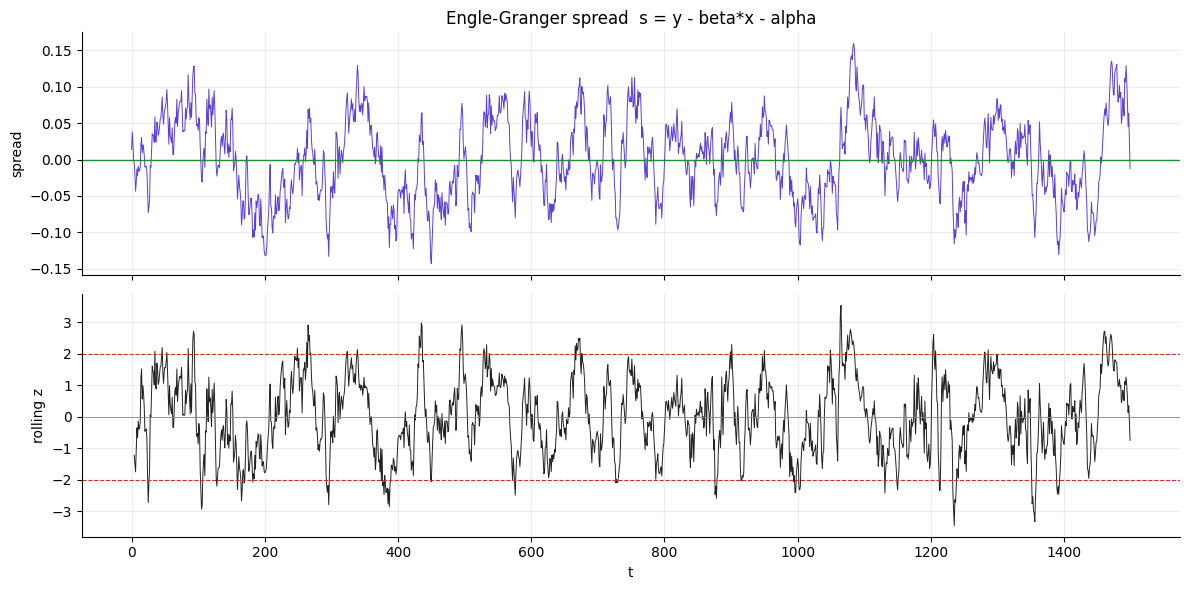

In [4]:
beta_hat, alpha_hat = float(eg_coint.beta[0]), eg_coint.alpha
sp = make_spread(log_y, log_x, beta_hat, alpha_hat)         # == eg_coint.residuals
z = rolling_zscore(sp, window=60)
print(f'spread half-life = {half_life(sp):.1f} bars   (OU mean reversion)')

fig, (axs, axz) = plt.subplots(2, 1, sharex=True, height_ratios=[1, 1], figsize=(12, 6))
axs.plot(sp, color='#5b3fd8', lw=0.7); axs.axhline(sp.mean(), color='#1f8e3a', lw=1)
axs.set_title('Engle-Granger spread  s = y - beta*x - alpha'); axs.set_ylabel('spread')
axz.plot(z, color='#222', lw=0.7); axz.axhline(0, color='#888', lw=0.6)
for lvl in (2, -2): axz.axhline(lvl, color='#c4302b', ls='--', lw=0.8)
axz.set_ylabel('rolling z'); axz.set_xlabel('t')
plt.tight_layout(); plt.show()


## 3. Johansen — rank and the error-correction view

The Johansen test asks: **how many** independent cointegrating relations exist
(the *rank*)? For a genuine pair the answer is exactly **1**. It reports:

* a **trace statistic** sequence (test rank=0, then ≤1, …) vs critical values,
* the **eigenvector** (the cointegrating vector → $\beta$),
* the **loadings** $\alpha$ — the *speed of adjustment*: how fast each leg is
  pulled back toward equilibrium (the heart of the error-correction model).


In [5]:
jres = johansen(np.column_stack([log_y, log_x]), k_ar_diff=1, det_order=0)
print(f'rank (trace, 5%) = {jres.rank_trace}   rank (max-eig, 5%) = {jres.rank_max_eig}')
print(f'\n{"r":>3}{"trace stat":>12}{"5% crit":>10}  reject H0(rank<=r)?')
for r in range(jres.k):
    rej = jres.trace_stats[r] > jres.trace_crits[r, 1]
    print(f'{r:>3}{jres.trace_stats[r]:>12.2f}{jres.trace_crits[r,1]:>10.2f}  {rej}')

vec = jres.eigenvectors[:, 0]
beta_joh = -vec[1] / vec[0]
# alpha and beta are jointly identified only up to a common scale, so the
# loadings' *signs* (not their raw magnitudes) carry the economic content:
# they give the error-correction direction. The spread half-life above is the
# interpretable measure of reversion speed.
load = jres.loadings[:, 0]
print(f'\nJohansen beta = {beta_joh:.3f}  (Engle-Granger {beta_hat:.3f}, true 0.80)')
print(f'error-correction loading signs (y, x) = '
      f'({"+" if load[0] >= 0 else "-"}, {"+" if load[1] >= 0 else "-"})  '
      '-> each leg is pulled back toward the spread equilibrium')


rank (trace, 5%) = 1   rank (max-eig, 5%) = 1

  r  trace stat   5% crit  reject H0(rank<=r)?
  0       53.18     15.41  True
  1        2.36      3.84  False

Johansen beta = 0.815  (Engle-Granger 0.814, true 0.80)
error-correction loading signs (y, x) = (-, -)  -> each leg is pulled back toward the spread equilibrium


## 4. Kalman dynamic hedge ratio — when $\beta$ drifts

A *static* $\beta$ assumes the relationship never changes. In reality hedge
ratios drift (index reweightings, regime shifts). The **`HedgeRatioFilter`**
models $\beta_t,\alpha_t$ as a random walk and updates them online with a
Kalman filter — no look-ahead. Here the true $\beta$ ramps from 0.7 to 1.3;
static OLS gives one compromise number, the Kalman tracks the path.


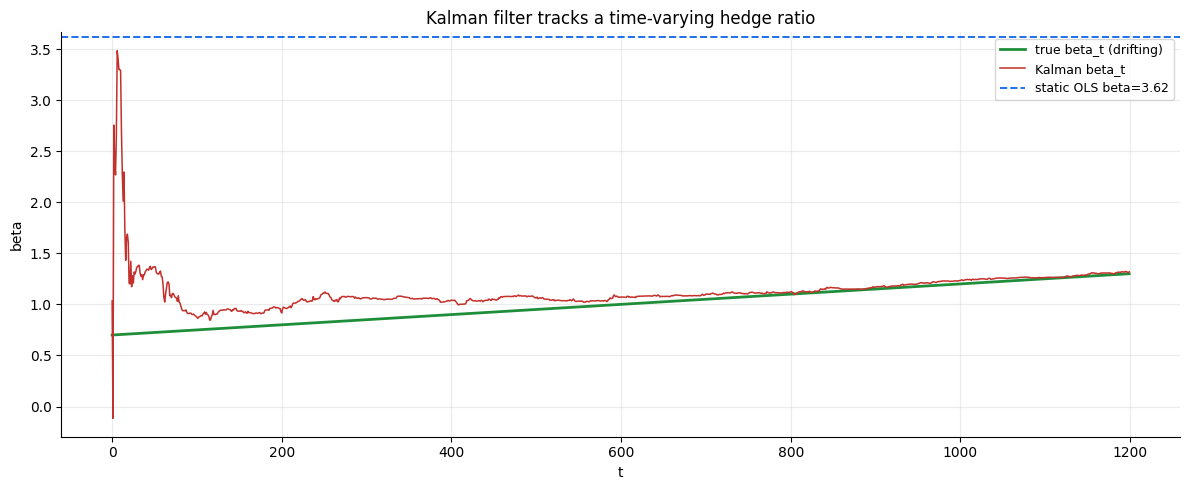

In [6]:
n2 = 1200
beta_path = np.linspace(0.7, 1.3, n2)                  # the truth drifts
lx = 3.0 + np.cumsum(rng.normal(0, 0.012, n2))
ly = 1.0 + beta_path * lx + rng.normal(0, 0.05, n2)

beta_ols = hedge_ratio(ly, lx, method='ols')
kf = HedgeRatioFilter(delta=1e-4, obs_var=0.05)
out = kf.filter(ly, lx)
beta_kf = out['beta'].to_numpy()

fig, ax = plt.subplots()
ax.plot(beta_path, color='#1f8e3a', lw=2.0, label='true beta_t (drifting)')
ax.plot(beta_kf, color='#c4302b', lw=1.1, label='Kalman beta_t')
ax.axhline(beta_ols, color='#1f6feb', lw=1.4, ls='--', label=f'static OLS beta={beta_ols:.2f}')
ax.set_title('Kalman filter tracks a time-varying hedge ratio'); ax.set_xlabel('t')
ax.set_ylabel('beta'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 5. A real pair — EWA / EWC — and screening a universe

**EWA** (iShares Australia) and **EWC** (iShares Canada) are the textbook
cointegrated ETF pair: two commodity-driven, resource-heavy economies whose
equity markets track each other. We load a small basket of single-country /
sector ETFs and let `screen_pairs` rank every pair by cointegration
significance, reporting the hedge ratio and half-life of each spread.


In [7]:
BASKET = ['EWA', 'EWC', 'EWG', 'EWU', 'GLD']

def load_basket(tickers=BASKET, start='2010-01-01', end='2024-12-31'):
    try:
        import yfinance as yf
        raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
        close = raw['Close'][tickers].dropna()
        if len(close) > 800:
            return close.to_numpy(dtype='float64'), list(close.columns)
    except Exception as exc:
        print(f'yfinance unavailable ({exc!r}); using synthetic basket with one cointegrated pair')
    m = 3000; r = np.random.default_rng(5)
    c = np.cumsum(r.normal(0, 0.011, m))
    ou_s = np.zeros(m)
    for t in range(1, m):
        ou_s[t] = 0.95 * ou_s[t-1] + r.normal(0, 0.02)
    ewa = np.exp(3.0 + c)
    ewc = np.exp(2.0 + 0.9 * (3.0 + c) + ou_s)        # cointegrated with EWA
    ewg = np.exp(3.2 + np.cumsum(r.normal(0, 0.011, m)))
    ewu = np.exp(3.1 + np.cumsum(r.normal(0, 0.011, m)))
    gld = np.exp(4.8 + np.cumsum(r.normal(0, 0.009, m)))
    return np.column_stack([ewa, ewc, ewg, ewu, gld]), list(tickers)

panel, names = load_basket()
print(f'basket: {panel.shape[0]} bars x {panel.shape[1]} assets: {names}\n')

pairs = screen_pairs(panel, names=names, method='engle_granger', alpha=0.10)
print(f'{"pair":<14}{"beta":>8}{"p-value":>10}{"half-life":>11}')
for r in pairs:
    print(f'{r.y + "~" + r.x:<14}{r.beta:>8.3f}{r.p_value:>10.4f}{r.half_life:>11.1f}')
if not pairs:
    print('(no pair passed the 10% cointegration gate over this sample)')


basket: 3773 bars x 5 assets: ['EWA', 'EWC', 'EWG', 'EWU', 'GLD']



pair              beta   p-value  half-life
EWA~EWC          0.968    0.0404       78.8
EWU~EWA          0.716    0.0800      135.9


EWA ~ EWC  beta=0.968  ADF p=0.0404  cointegrated=True  half-life=78.8 bars


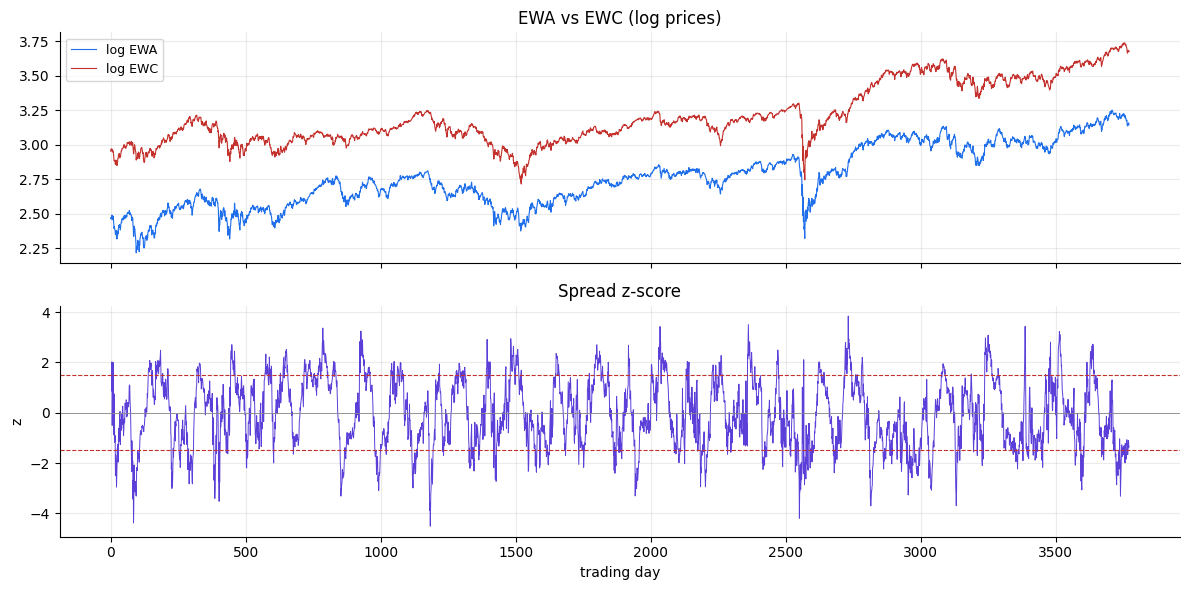

In [8]:
ia, ic = names.index('EWA'), names.index('EWC')
ewa, ewc = panel[:, ia], panel[:, ic]
eg = engle_granger(np.log(ewa), np.log(ewc), trend='c')
sp = eg.residuals
print(f'EWA ~ EWC  beta={float(eg.beta[0]):.3f}  ADF p={eg.p_value:.4f}  '
      f'cointegrated={eg.cointegrated}  half-life={half_life(sp):.1f} bars')

z = rolling_zscore(sp, window=60)
fig, (axp, axz) = plt.subplots(2, 1, sharex=True, height_ratios=[1, 1], figsize=(12, 6))
axp.plot(np.log(ewa), color='#1f6feb', lw=0.8, label='log EWA')
axp.plot(np.log(ewc), color='#c4302b', lw=0.8, label='log EWC')
axp.set_title('EWA vs EWC (log prices)'); axp.legend(fontsize=9)
axz.plot(z, color='#5b3fd8', lw=0.7); axz.axhline(0, color='#888', lw=0.6)
for lvl in (1.5, -1.5): axz.axhline(lvl, color='#c4302b', ls='--', lw=0.8)
axz.set_title('Spread z-score'); axz.set_xlabel('trading day'); axz.set_ylabel('z')
plt.tight_layout(); plt.show()


## 6. Hand-off — the `CointegrationPairsStrategy`

The full strategy is causal and self-defending: it **re-runs Engle–Granger on a
rolling window**, only trades while the cointegration gate is open
(p-value < `eg_alpha`), and stands flat when the relationship breaks down. It
returns both legs' positions ($pos_x=-\beta\,pos_y$) so the book is
market-neutral.


Cointegration Pairs Summary
  Sharpe (ann.)   : 0.2670
  Total return    : 22.01%
  Max drawdown    : -14.39%
  Num trades      : 36
  Active fraction : 25.8%
  Avg |z_score|   : 1.137


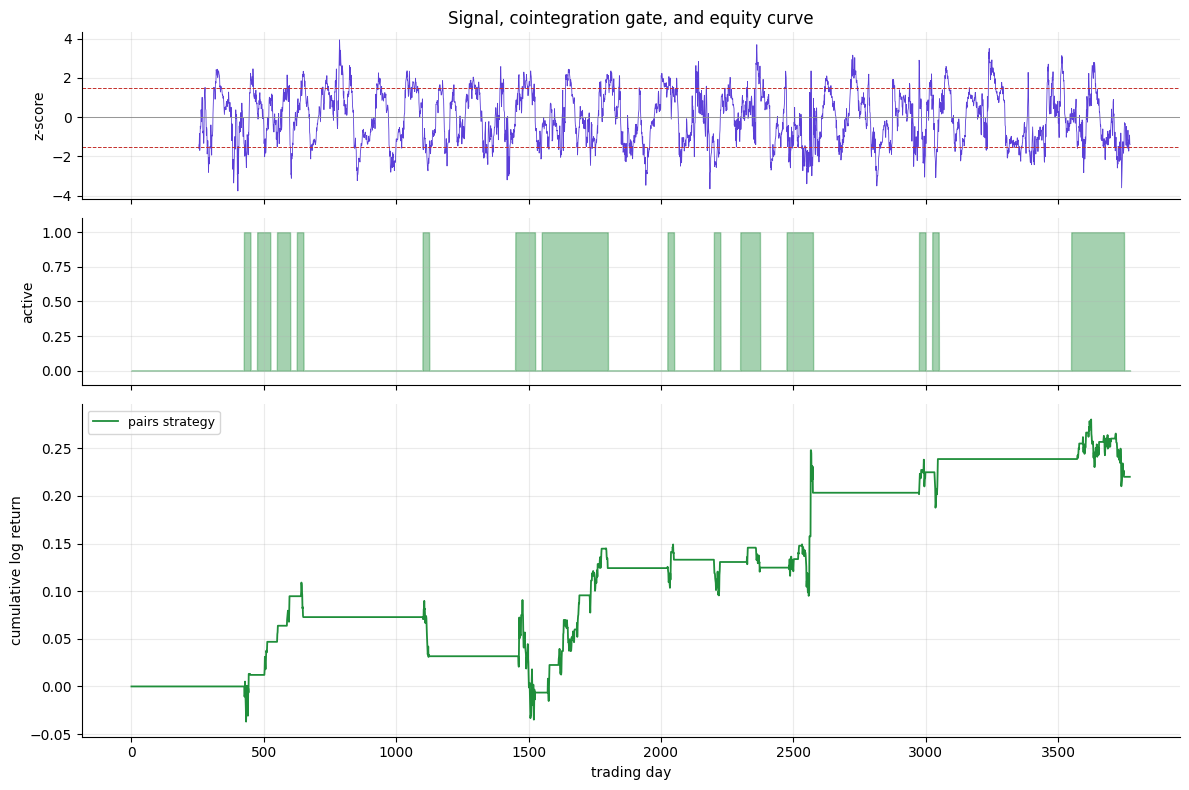

In [9]:
strat = CointegrationPairsStrategy(PairsParams(
    fit_window=250, refit_every=25, zscore_window=60,
    eg_alpha=0.10, entry_z=1.5, exit_z=0.3, stop_z=4.0))
res = strat.run(ewa, ewc)
print(res.summary())

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 8),
                         gridspec_kw={'height_ratios': [1, 1, 2]})
axes[0].plot(res.z_score, color='#5b3fd8', lw=0.6); axes[0].axhline(0, color='#888', lw=0.6)
for lvl in (1.5, -1.5): axes[0].axhline(lvl, color='#c4302b', ls='--', lw=0.7)
axes[0].set_ylabel('z-score'); axes[0].set_title('Signal, cointegration gate, and equity curve')
axes[1].fill_between(range(len(res.active)), res.active.astype(float), color='#1f8e3a', alpha=0.4)
axes[1].set_ylabel('active'); axes[1].set_ylim(-0.1, 1.1)
axes[2].plot(np.nancumsum(res.log_returns), color='#1f8e3a', lw=1.3, label='pairs strategy')
axes[2].set_ylabel('cumulative log return'); axes[2].set_xlabel('trading day'); axes[2].legend(fontsize=9)
plt.tight_layout(); plt.show()


## What next?

* **VECM.** `qufin.timeseries.vecm` fits the full vector error-correction model
  the Johansen test implies — useful for *forecasting* both legs jointly, not
  just trading the spread.
* **Costs & capacity.** Pairs turn over frequently; net the `log_returns`
  against a per-trade cost and watch the Sharpe before believing it.
* **Baskets, not just pairs.** Johansen with rank > 1 finds multiple
  cointegrating relations across a sector — trade a stationary portfolio of
  several names.
* **Mind the break.** Cointegration can vanish (a merger, a policy shift). The
  rolling p-value gate here is the first line of defence; pair it with a
  structural-break or regime model for the second.
